# Proyecto TFG Radiación en entornos urbanos

### Pasos de este estudio
1. Carga de datos
1. Exploración
1. Procesamiento
1. Modelos
1. Evaluación
1. Predicción
1. Conclusión y próximos pasos

# Analisis de datos de red de piranómetros

## 1. Cargando datos

In [16]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib as mpl
import matplotlib.cm as cm
import datetime

In [126]:
def parser(s):
    return datetime.datetime.strptime(s, '%Y-%m-%d')

In [127]:
#datos = pd.read_csv('../csv/rad_20250419.csv', sep=',', parse_dates=["timestamp"], date_parser=parser)
#datos.shape

In [145]:
# lectura de datos en Python
datos = pd.read_csv('../csv/rad_20250420.csv')

In [146]:
datos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11520 entries, 0 to 11519
Data columns (total 15 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   timestamp  11520 non-null  object 
 1   P1         11520 non-null  float64
 2   P2         11520 non-null  float64
 3   P3         11520 non-null  float64
 4   P4         11520 non-null  float64
 5   P5         11520 non-null  float64
 6   P6         11520 non-null  float64
 7   P7         11520 non-null  float64
 8   P8         11520 non-null  float64
 9   P9         11520 non-null  float64
 10  P0         11520 non-null  float64
 11  PH         11520 non-null  float64
 12  Pinc       11520 non-null  float64
 13  ws         11520 non-null  float64
 14  temp       11520 non-null  float64
dtypes: float64(14), object(1)
memory usage: 1.3+ MB


## 2. Explorando datos

In [147]:
# que columnas tienen los datos?
datos.columns

Index(['timestamp', 'P1', 'P2', 'P3', 'P4', 'P5', 'P6', 'P7', 'P8', 'P9', 'P0',
       'PH', 'Pinc', 'ws', 'temp'],
      dtype='object')

In [148]:
datos.head()

,timestamp,P1,P2,P3,P4,P5,P6,P7,P8,P9,P0,PH,Pinc,ws,temp
0,2025-04-20 06:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.5,7.0
1,2025-04-20 06:00:05,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.4,7.0
2,2025-04-20 06:00:10,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.4,7.0
3,2025-04-20 06:00:15,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.7,7.0
4,2025-04-20 06:00:20,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.5,7.0


In [149]:
# qué tamaño tienen los datos?
datos.shape

(11520, 15)

In [150]:
# como se distribuyen las variables numéricas
datos.describe()

,P1,P2,P3,P4,P5,P6,P7,P8,P9,P0,PH,Pinc,ws,temp
count,11520.000000,11520.000000,11520.000000,11520.000000,11520.000000,11520.000000,11520.000000,11520.000000,11520.000000,11520.000000,11520.000000,11520.000000,11520.000000,11520.000000
mean,374.202205,333.219870,369.818767,369.962934,369.165286,370.653802,365.948793,372.123229,366.918082,373.069375,303.152396,370.544002,1.870530,14.167491
std,331.904171,308.407893,331.741008,328.620743,333.175083,327.472536,332.115938,329.728372,323.593448,330.857410,396.328117,353.424277,1.423275,3.956193
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.900000
25%,35.475000,33.375000,33.075000,35.100000,32.375000,34.500000,32.100000,34.000000,33.600000,35.175000,0.000000,31.000000,0.800000,12.400000
50%,329.600000,266.900000,324.450000,321.750000,326.150000,324.800000,327.600000,325.400000,326.250000,328.150000,15.000000,283.850000,1.600000,15.100000
75%,603.625000,544.325000,596.725000,595.325000,600.925000,604.800000,595.500000,599.725000,596.100000,598.600000,788.925000,618.175000,2.800000,17.400000
max,1396.000000,1341.000000,1425.000000,1439.600000,1466.400000,1436.000000,1446.400000,1440.400000,1417.600000,1426.600000,1007.400000,1559.400000,8.800000,20.100000


In [151]:
# como se comportan las variables categóricas
datos.describe(include=['O'])

,timestamp
count,11520
unique,11520
top,2025-04-20 06:00:00
freq,1


In [152]:
datos['timestamp'] = pd.to_datetime(datos['timestamp']) #.dt.strftime('%H:%M:%S')

In [153]:
datos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11520 entries, 0 to 11519
Data columns (total 15 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   timestamp  11520 non-null  datetime64[ns]
 1   P1         11520 non-null  float64       
 2   P2         11520 non-null  float64       
 3   P3         11520 non-null  float64       
 4   P4         11520 non-null  float64       
 5   P5         11520 non-null  float64       
 6   P6         11520 non-null  float64       
 7   P7         11520 non-null  float64       
 8   P8         11520 non-null  float64       
 9   P9         11520 non-null  float64       
 10  P0         11520 non-null  float64       
 11  PH         11520 non-null  float64       
 12  Pinc       11520 non-null  float64       
 13  ws         11520 non-null  float64       
 14  temp       11520 non-null  float64       
dtypes: datetime64[ns](1), float64(14)
memory usage: 1.3 MB


In [154]:
#Pintar una line plot
#fig = plt.figure()
#ax = fig.add_subplot(111)
#piranometers=["P0","P1","P2","P3","P4","P5","P6","P7","P8","P9","Pinc","PH"]
#for col in piranometers:
    #sns.lineplot(x="timestamp",y=col,data=datos,label=col)
#plt.xticks(rotation = 25,fontsize=7)
#ax.legend(title="Piranometros")

<Figure size 1000x400 with 0 Axes>

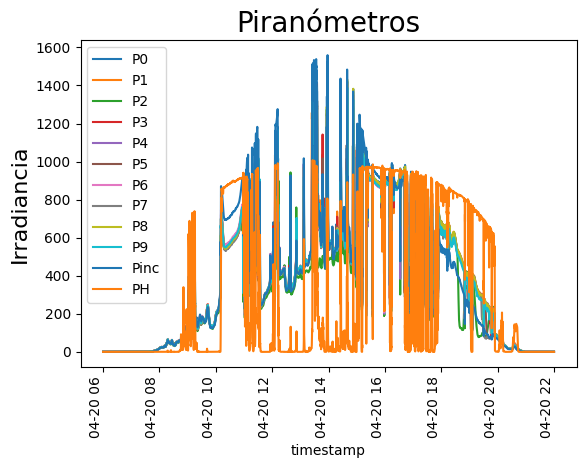

In [155]:
plt.figure(figsize=(10,4))
fig, ax = plt.subplots()
#plt.plot(x="timestamp",y="P0")
piranometers=["P0","P1","P2","P3","P4","P5","P6","P7","P8","P9","Pinc","PH"]
for col in piranometers:
    sns.lineplot(x="timestamp",y=col,data=datos,label=col)
plt.title(f'Piranómetros', fontsize=20)
plt.ylabel('Irradiancia', fontsize=16)

fig.autofmt_xdate(rotation=90)